# Análisis de los datos

In [1]:
from extraccion import minioFunctions as mf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

Se presenta un análisis detallado de las variables regresoras que serán empleadas para el modelo que predice la probabilidad de incendio dada una latitud y longitud, así como las correlaciones entre ellas y con la variable objetivo

### **Características de las variables**

In [2]:
l_f = []
for k in [2022, 2023,2024, 2025]:
    print(f"Analizando el año {k}:")
    dataf = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/cleaned/modelo_General_{k}.parquet", type="df")
    l_f.append(dataf)
dataFrame = pd.concat(l_f, ignore_index=True)

Analizando el año 2022:
Dataframe importado correctamente
Analizando el año 2023:
Dataframe importado correctamente
Analizando el año 2024:
Dataframe importado correctamente
Analizando el año 2025:
Dataframe importado correctamente


In [3]:
df_final = dataFrame.copy()

**COMPOSICIÓN DEL DATASET**

Las variables son:

In [4]:
print(f"Variables: {df_final.columns}")

Variables: Index(['lat', 'lon', 'date', 'final', 'elevacion_centro', 'grados',
       'porcentaje', 'temp_mean', 'temp_max', 'temp_min', 'humidity_mean',
       'precipitation', 'wind_speed_max', 'wind_gusts_max', 'pressure_mean',
       'cloud_cover', 'radiation', 'evapotranspiration', 'sunshine_seconds',
       'NDVI', 'NDWI'],
      dtype='str')


In [6]:
cliente = mf.crear_cliente()
final = mf.bajar_fichero(cliente, "grupo3/cleaned/MINI.parquet","df")
final.columns

Dataframe importado correctamente


Index(['lat', 'lon', 'date', 'soil_temp', 'final', 'elevacion_centro',
       'grados', 'porcentaje', 'temp_mean', 'temp_max', 'temp_min',
       'humidity_mean', 'precipitation', 'wind_speed_max', 'wind_gusts_max',
       'pressure_mean', 'cloud_cover', 'radiation', 'evapotranspiration',
       'sunshine_seconds', 'NDVI', 'NDWI', 'dist_civ', 'dia_sin', 'dia_cos'],
      dtype='str')

Total de filas y proporción de incendios y no incendios:

In [5]:
total = len(df_final)
total_incendios = len(df_final[df_final['final'] == 1])
total_no_incendios = len(df_final[df_final['final'] == 0])
print(f"La longitud total de los datos es de: {total}")
print(f"Proporción de incendios: {np.round(total_incendios * 100 / total, 2)} %")
print(f"Proporción de no incendios: {np.round(total_no_incendios * 100 / total, 2)} %")

La longitud total de los datos es de: 71444
Proporción de incendios: 3.76 %
Proporción de no incendios: 96.24 %


Representación primeras filas del dataset:

In [6]:
print(df_final.head(10))

         lat        lon       date  final  elevacion_centro     grados  \
0  34.940922  32.478487 2022-06-22      0        232.554901  15.533253   
1  34.951754  32.483892 2022-04-22      0        251.324463   7.779768   
2  34.959053  32.521256 2022-08-22      0        273.531555   7.937498   
3  34.961834  32.444368 2022-06-22      0        320.596954  16.206121   
4  34.967268  32.435256 2022-04-22      0        274.819000  10.585607   
5  34.977097  32.470616 2022-07-22      0        128.463608  23.943657   
6  34.980346  32.392628 2022-07-22      0        383.755280  16.072320   
7  34.987872  32.542161 2022-03-22      0        368.368774   7.168215   
8  34.992342  32.432700 2022-02-22      0        156.731934  10.129428   
9  34.992755  32.417797 2022-09-22      0        268.785706  11.545950   

   porcentaje  temp_mean  temp_max  temp_min  ...  precipitation  \
0   27.794965       25.7      30.5      20.5  ...            0.0   
1   13.662323       16.1      21.8       9.4  ...

**VARIABLE OBJETIVO**

La varible objetivo es una variable binaria --> 0 indica no-incendio y 1, incendio.

In [7]:
print(df_final['final'].unique())

[0 1]


**INFORMACIÓN DEL TIPO DE VARIABLES**

In [8]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 71444 entries, 0 to 71443
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   lat                 71444 non-null  float64       
 1   lon                 71444 non-null  float64       
 2   date                71444 non-null  datetime64[us]
 3   final               71444 non-null  int64         
 4   elevacion_centro    71444 non-null  float64       
 5   grados              71444 non-null  float64       
 6   porcentaje          71444 non-null  float64       
 7   temp_mean           71444 non-null  float64       
 8   temp_max            71444 non-null  float64       
 9   temp_min            71444 non-null  float64       
 10  humidity_mean       71444 non-null  float64       
 11  precipitation       71444 non-null  float64       
 12  wind_speed_max      71444 non-null  float64       
 13  wind_gusts_max      71444 non-null  float64       
 14  p

**INFORMACIÓN ESTADÍSTICA DE LAS VARIABLES**

Evaluar la distribución de la variable objetivo (porque es binaria) y de la fecha, y su información estadística resulta irrelevante.

Eliminamos también la latitud y longitud, ya que posteriormente se realizará un gráfico en forma de mapa.

Más tarde se hará un análisis de incendios y de datos basado en los meses.

In [9]:
df = df_final.drop(columns = ['final', 'date', 'lat', 'lon']) 
df.describe()

,elevacion_centro,grados,porcentaje,temp_mean,temp_max,temp_min,humidity_mean,precipitation,wind_speed_max,wind_gusts_max,pressure_mean,cloud_cover,radiation,evapotranspiration,sunshine_seconds,NDVI,NDWI
count,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000,71444.000000
mean,412.587686,6.523116,11.841478,11.643895,16.351846,7.223571,71.561251,2.139403,16.589919,36.632575,968.513308,54.584038,14.513500,2.729884,31156.473745,0.445047,-0.436926
std,429.766258,7.755343,14.865904,8.951396,9.975310,8.174689,15.778236,5.493580,6.642947,13.372159,47.876438,33.316980,8.582497,2.038158,16106.798699,0.246807,0.210546
min,-4.915385,0.001124,0.001961,-25.600000,-22.800000,-30.000000,9.000000,0.000000,1.600000,6.500000,646.800000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000
25%,104.385832,0.950033,1.658272,5.400000,9.400000,1.500000,61.000000,0.000000,11.700000,27.000000,945.200000,25.000000,7.300000,1.040000,21195.302500,0.235958,-0.604346
50%,247.203384,3.341336,5.838352,11.500000,16.100000,7.400000,74.000000,0.000000,15.600000,34.900000,984.400000,58.000000,13.960000,2.240000,34052.300000,0.442799,-0.447827
75%,604.038635,9.415966,16.583523,18.100000,23.500000,13.100000,84.000000,1.600000,20.400000,43.900000,1003.100000,86.000000,22.070000,4.150000,44140.607500,0.652084,-0.297466
max,3606.814453,61.469063,183.940168,39.000000,48.000000,33.500000,100.000000,171.200000,63.400000,145.400000,1045.800000,100.000000,32.850000,12.360000,76364.840000,1.000000,1.000000


**DISTRIBUCIÓN DE LAS VARIABLES NUMÉRICAS**

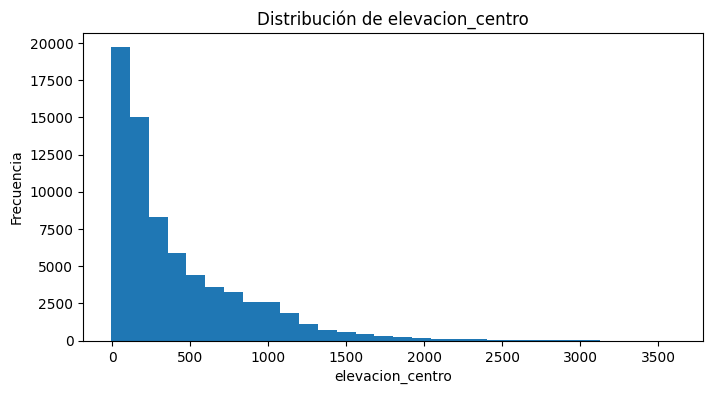

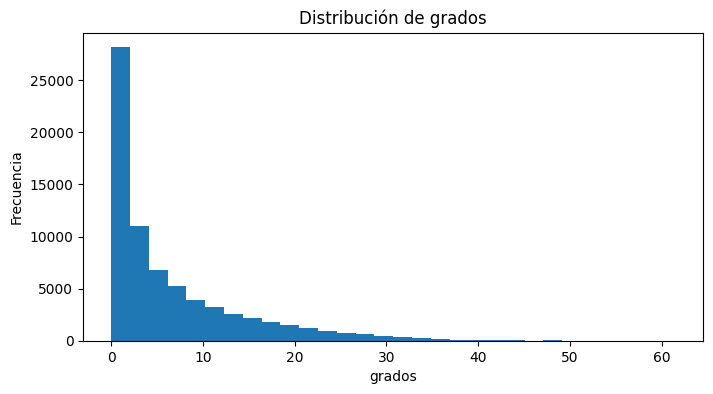

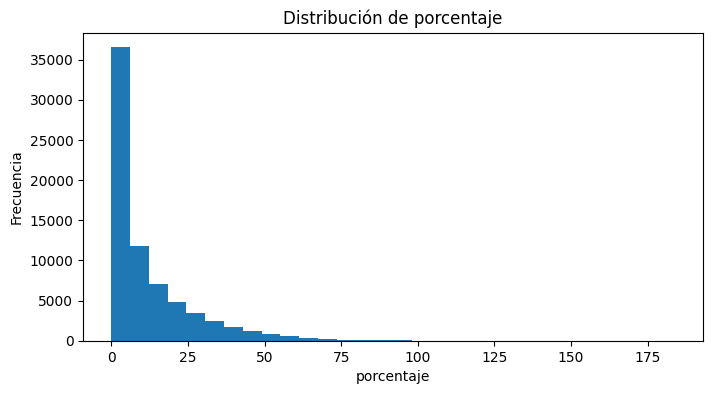

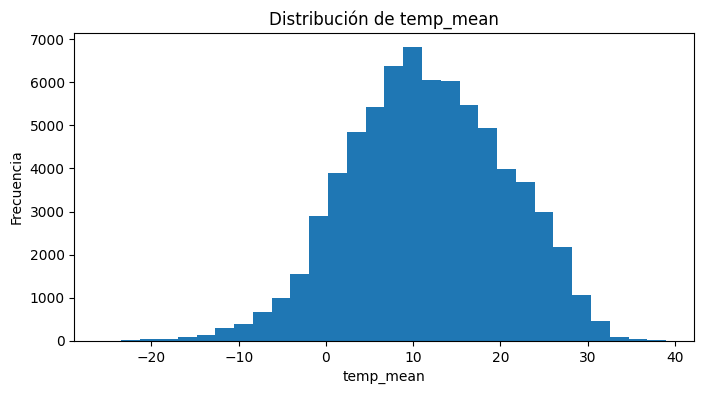

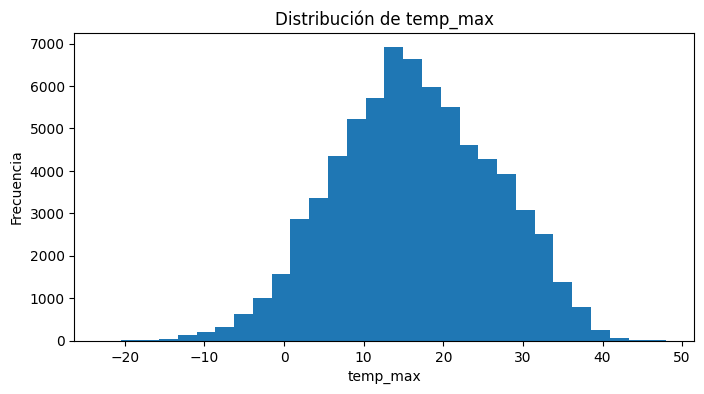

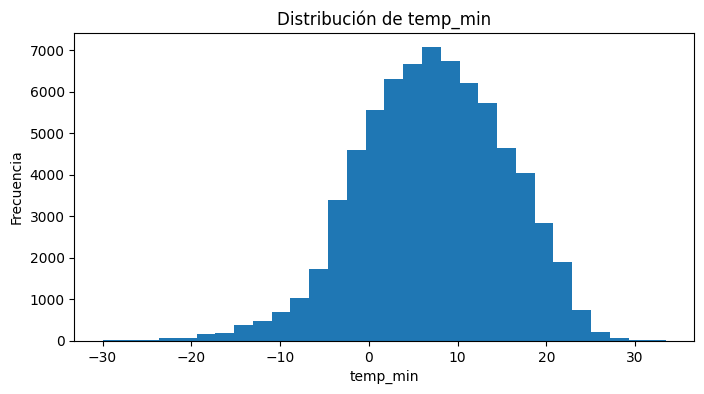

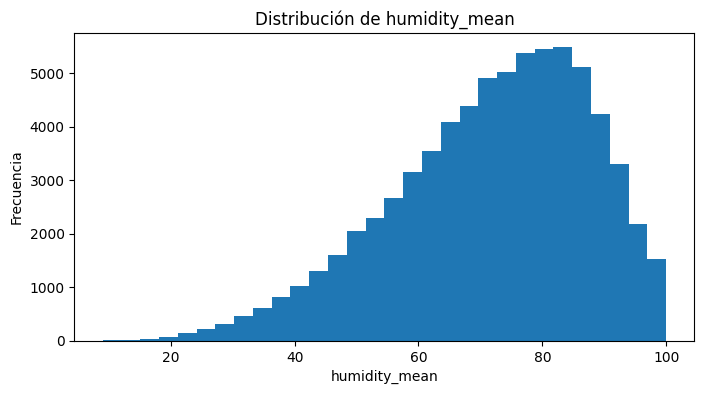

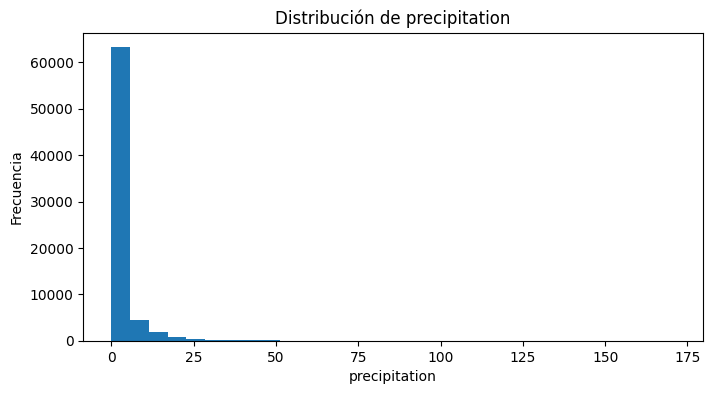

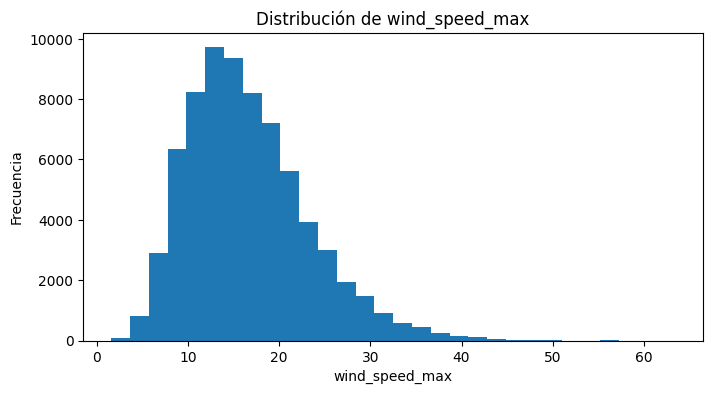

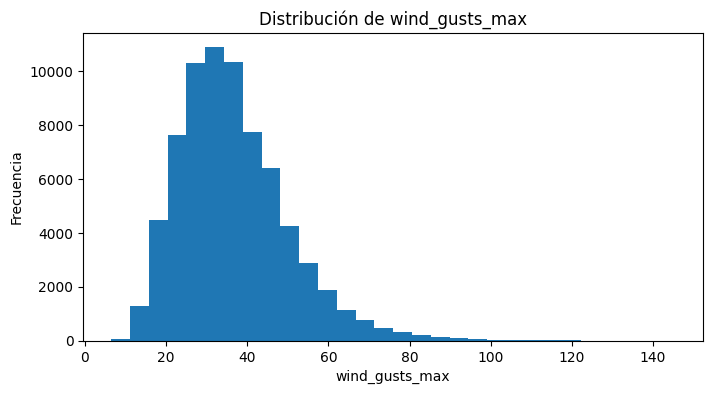

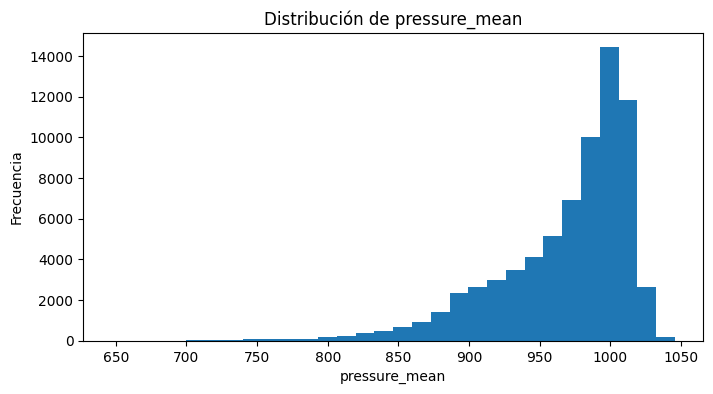

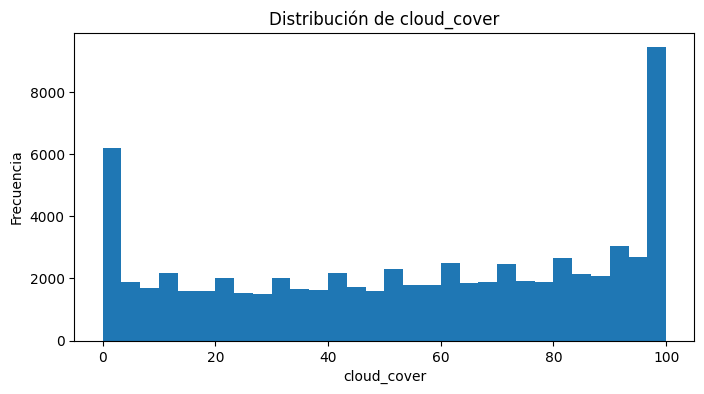

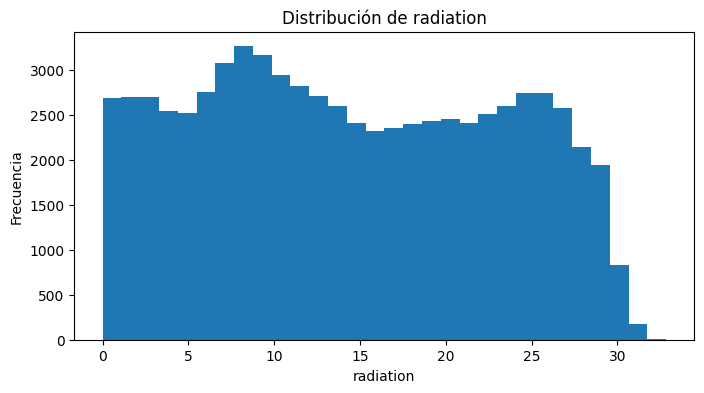

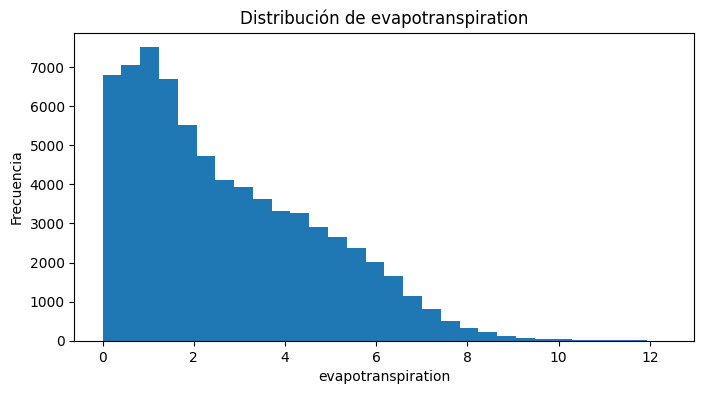

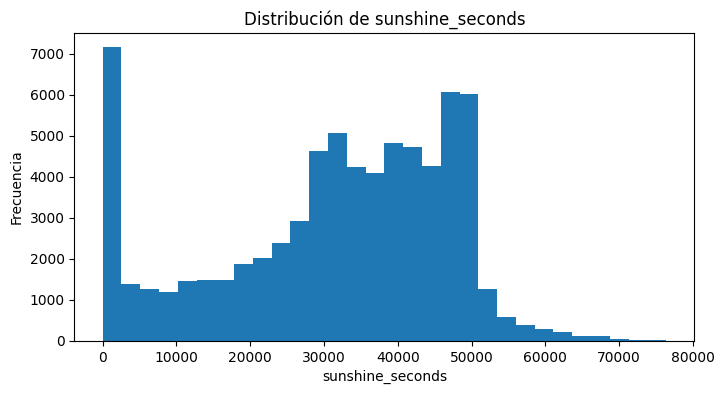

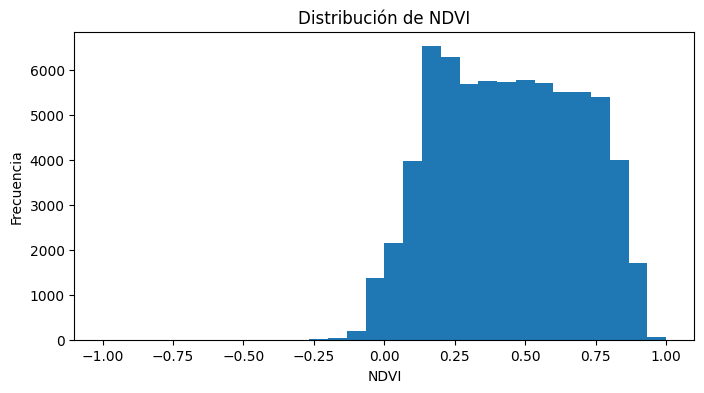

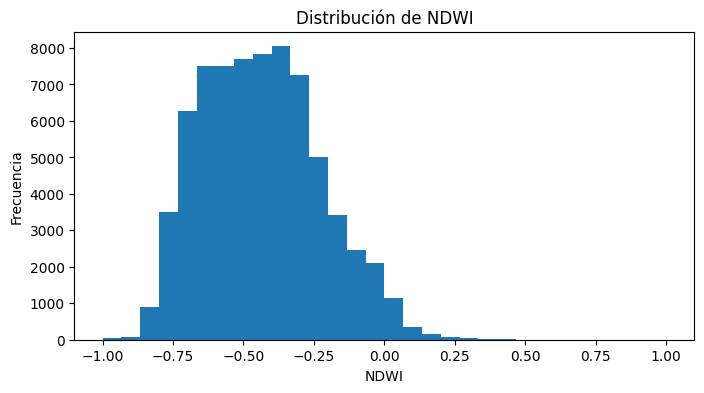

In [10]:
for col in df.columns:
    plt.figure(figsize=(8, 4))
    df[col].hist(bins=30)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.grid(False)
    plt.show()

**DISTRIBUCIÓN DE LOS INCENDIOS Y DE LOS DATOS POR LATITUD Y LONGITUD**

Se quiere evaluar si hay una distribución equitativa de los datos, como se pretendía con la obtención de los datos de no incendio, así como evaluar las zonas donde el riesgo de incendio es mayor.

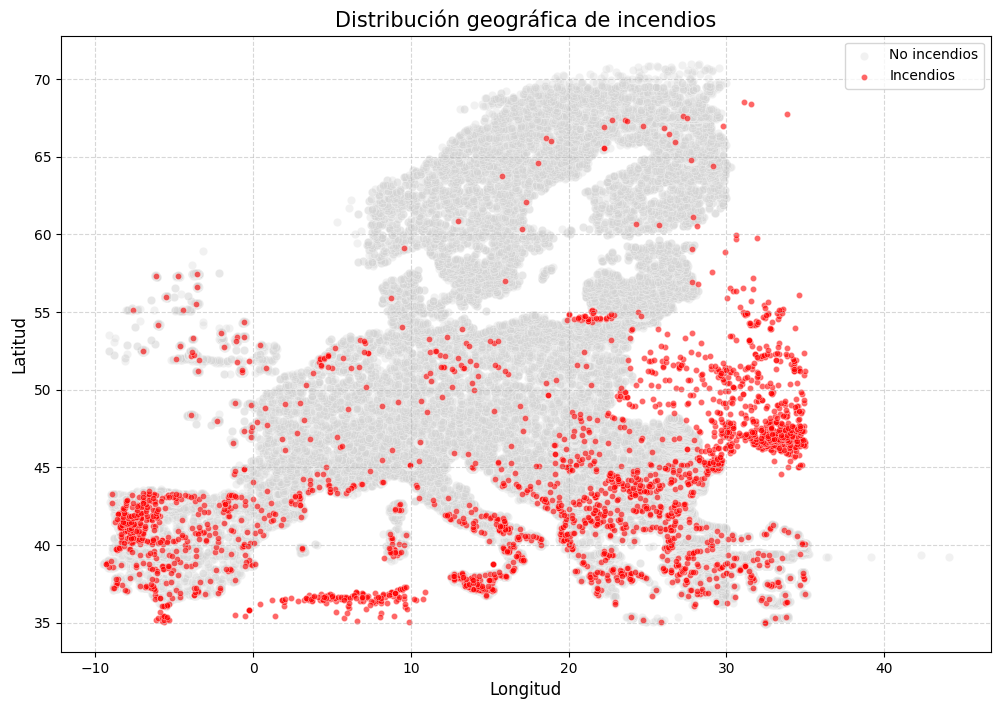

In [28]:
plt.figure(figsize=(12, 8))

sns.scatterplot(data=df_final[df_final['final'] == 0], x='lon', y='lat', color='lightgrey', alpha=0.3, label='No incendios')

sns.scatterplot(data=df_final[df_final['final'] == 1], x='lon', y='lat', color='red', alpha=0.6, s=20, label='Incendios')

plt.title('Distribución geográfica de incendios', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Llevamos a cabo un análisis de los datos que son de Ucrania. 

Consideramos que estos puntos pueden haber sido provocados por la guerra con Rusia desde 2022, por lo que decidimos eliminarlos.

Geodataframe importado correctamente


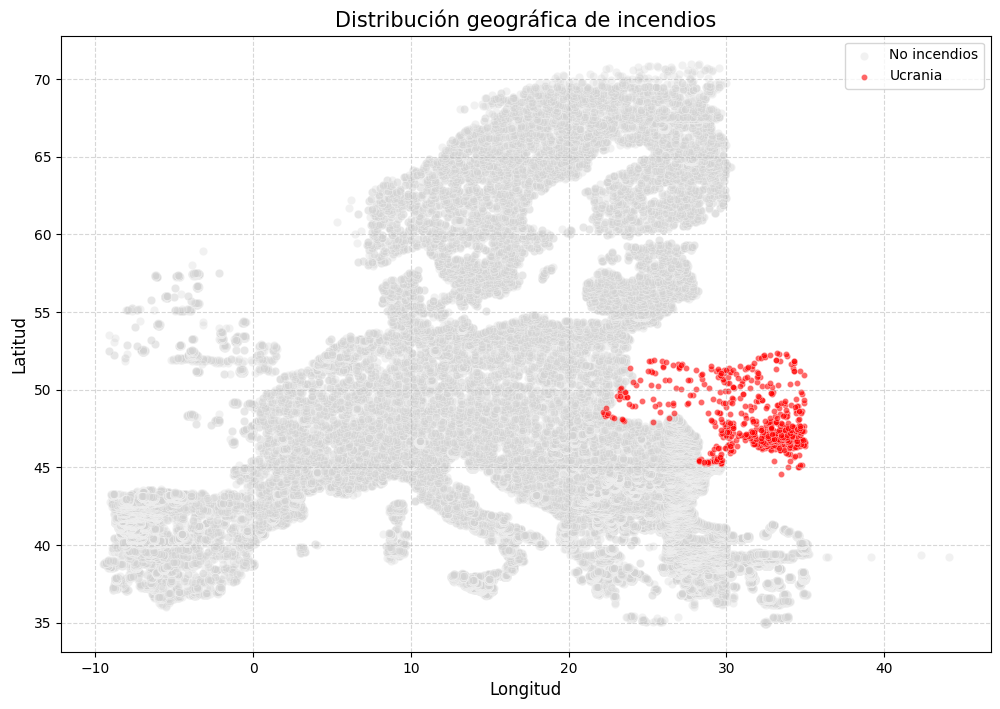

In [29]:
from extraccion import filtros_no_incendio

cliente = mf.crear_cliente()
df_ucrania = filtros_no_incendio.filtrar_zona_eliminar("grupo3/raw/Countries/mascara_Ukraine.parquet", df_final, cliente)

plt.figure(figsize=(12, 8))

sns.scatterplot(data=df_final[df_final['final'] == 0], x='lon', y='lat', color='lightgrey', alpha=0.3, label='No incendios')

sns.scatterplot(data=df_ucrania, x='lon', y='lat', color='red', alpha=0.6, s=20, label='Ucrania')

plt.title('Distribución geográfica de incendios', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [30]:
total_datos = len(df_final)
total_incendios = len(df_final[df_final['final'] == 1])
total_ucrania = len(df_ucrania)

print(f"Total de datos en Ucrania: {total_ucrania}")
print(f"Proporción de datos en Ucrania con respecto al total: {np.round(total_ucrania * 100/total_datos)} %")
print(f"Proporción de datos en Ucrania con respecto al número de incendios: {np.round(total_ucrania * 100/total_incendios)} %")

Total de datos en Ucrania: 676
Proporción de datos en Ucrania con respecto al total: 1.0 %
Proporción de datos en Ucrania con respecto al número de incendios: 25.0 %


**DISTRIBUCIÓN DE INCENDIOS POR MESES**

Se quiere evaluar la distribución de los incendios por meses, para conocer qué meses presentan un mayor riesgo de incendio.

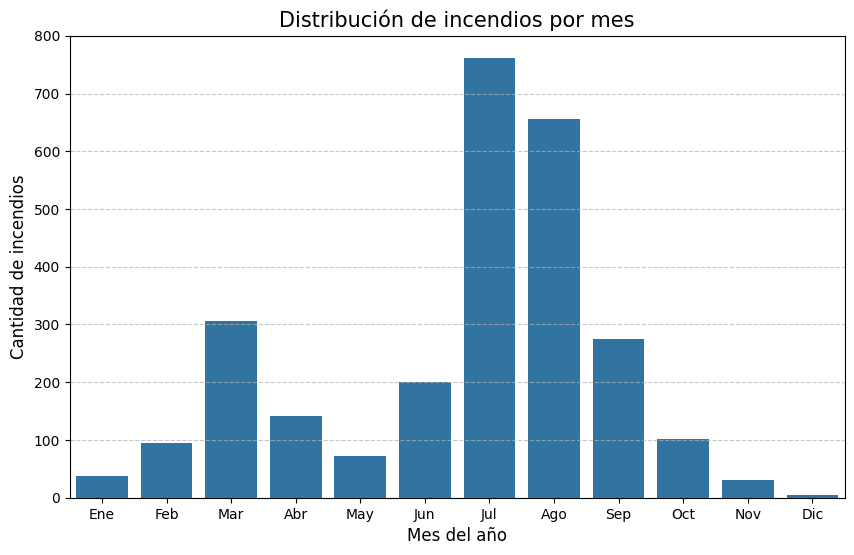

In [31]:
df_final['month'] = df_final['date'].dt.month
df_incendios = df_final[df_final['final'] == 1]

plt.figure(figsize=(10, 6))
sns.countplot(data=df_incendios, x='month')

plt.title('Distribución de incendios por mes', fontsize=15)
plt.xlabel('Mes del año', fontsize=12)
plt.ylabel('Cantidad de incendios', fontsize=12)
plt.xticks(ticks=range(0, 12), labels=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Se observa que la mayoría de incendios se concentran en julio y agosto, principalmente.

**DISTRIBUCIÓN DE LOS DATOS POR MES**

Queremos evaluar si la distribución de los datos es equitativa tras la obtención de datos de no incendio.

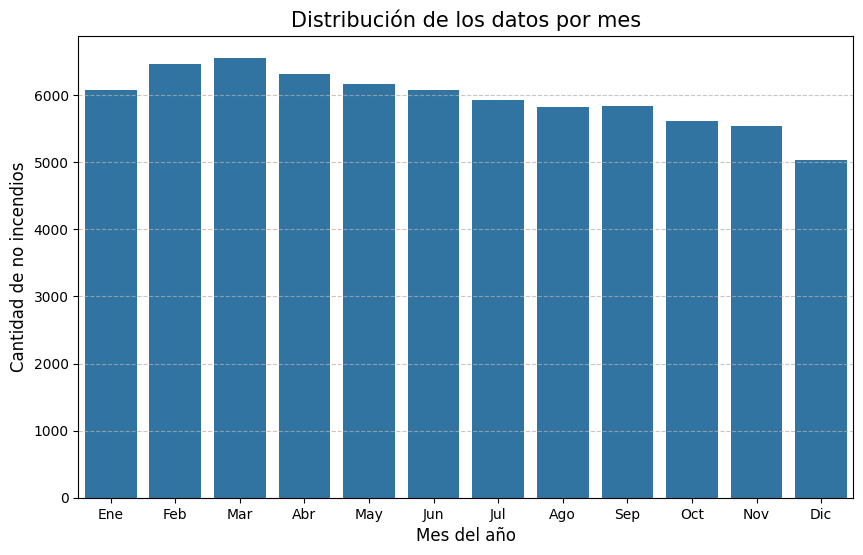

In [32]:
df_final['month'] = df_final['date'].dt.month

plt.figure(figsize=(10, 6))
sns.countplot(data=df_final, x='month')

plt.title('Distribución de los datos por mes', fontsize=15)
plt.xlabel('Mes del año', fontsize=12)
plt.ylabel('Cantidad de no incendios', fontsize=12)
plt.xticks(ticks=range(0, 12), labels=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Se abandona en este punto el análisis, ya que hay que llevar a cabo un limpieza y reconstrucción del dataset, para sanear las zonas donde no hay puntos de no incendio y eliminar los incendios de Ucrania.